# Pipeline Project

This goal of this project is to develop a pipeline which will analyze review texts and data and predict customer recommendations.  

The model will analyze the text of a review, the customer's age, the product category, and other relevant information to predict whether or not the customer would recommend the product.


# Includes and installs

In [1]:
%%capture
# Needed in udacity workspace:
# !pip3 install torch torchvision

In [2]:
%%capture
# Needed in udacity workspace:
"""
nlp_download_path = (
    "https://github.com/"
    "explosion/spacy-models/releases/download/"
    "en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl"
)

!pip install {nlp_download_path}
"""

In [3]:
import pandas as pd
import numpy as np
import spacy
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
import joblib
import pickle

from IPython.display import display

from pathlib import Path

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification

from scipy import sparse
from scipy.stats import randint, uniform

# Saved models and re-training

We define several variables to steer the flow of this project notebook:
- ***small_model***
  - Sentiment analysis puts a very big load on computing ressources. Using the small model will deactivate the sentiment analalysis whilst keeping the remaining pipeline intact.
- ***retrain***
  - This variable will define if the pipeline will be trained from scratch or (if available) pre-trained pipeline components will be loaded
- ***fit_small_load_big***
  - This variable is for demo or validation usage. It allows (with *small_model* and *retrain*) to fit the feature engineering part of the pipeline with the small model but afterwards load the big model (if available) for fitting the random forest.
- ***save_model***
  - This variable defines if the pipeline components will be saved after fitting
- ***model_path***
  - This variable defines where pipeline componments are saved to or loaded from

In [4]:
# Use the small model without sentiment analysis?
small_model = True

# Retrain the model? If False then use saved training data.
retrain = True

# Use this if you want to train the small model but load the big model
fit_small_load_big = True

# After training save model to file?
save_model = True

# Model folder
model_path = "./model"

## The Data

The dataset has been anonymized and cleaned of missing values.

There are 8 features for to use to predict whether a customer recommends or does
not recommend a product.
The `Recommended IND` column gives whether a customer recommends the product
where `1` is recommended and a `0` is not recommended.
This is your model's target/

The features can be summarized as the following:

- **Clothing ID**: Integer Categorical variable that refers to the specific piece being reviewed.
- **Age**: Positive Integer variable of the reviewers age.
- **Title**: String variable for the title of the review.
- **Review Text**: String variable for the review body.
- **Positive Feedback Count**: Positive Integer documenting the number of other customers who found this review positive.
- **Division Name**: Categorical name of the product high level division.
- **Department Name**: Categorical name of the product department name.
- **Class Name**: Categorical name of the product class name.

The target:
- **Recommended IND**: Binary variable stating where the customer recommends the product where 1 is recommended, 0 is not recommended.

## Load Data

In [5]:
# Load data
df = pd.read_csv(
    './data/reviews.csv',
)

df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## Preparing features (`X`) & target (`y`)

In [6]:
data = df

# separate features from labels
X = data.drop('Recommended IND', axis=1)
y = data['Recommended IND'].copy()

print('Labels:', y.unique())
print('Features:')
display(X.head())

Labels: [0 1]
Features:


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [7]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    shuffle=True,
    random_state=27,
)

## Data Exploration

### Categories

Already seen in previous cell we have no empty cells in any of the columns.

We have the following categories of data:

- **Categorical Data**
  - Clothing ID
  - Division Name
  - Department Name
- **Numerical Data**
  - Age
  - Positive Feedback Count
- **Text Data**
  - Title
  - Review Text

### Distribution of Data

Let's have a look at the **age distribution** of the reviewers

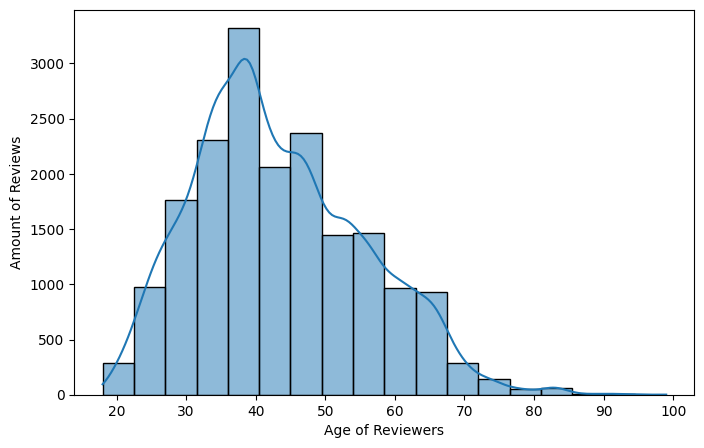

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(X["Age"], kde=True, bins=18)
plt.xlabel("Age of Reviewers")
plt.ylabel("Amount of Reviews")
plt.show()


Let's have a look at the **division** of the reviewed articles

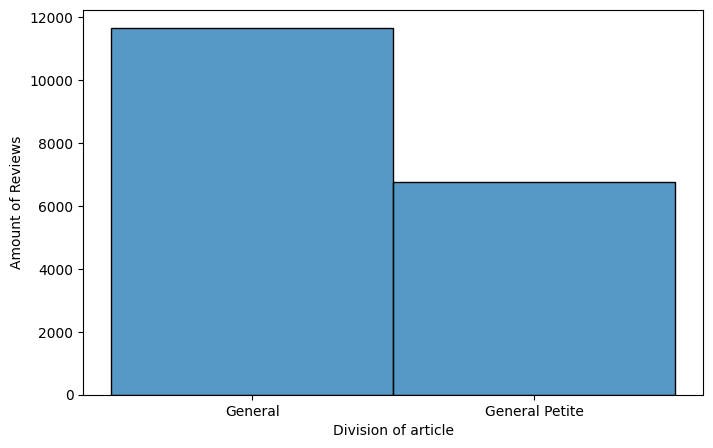

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(X["Division Name"])
plt.xlabel("Division of article")
plt.ylabel("Amount of Reviews")
plt.show()

Let's have a look at the **department** of the reviewed articles

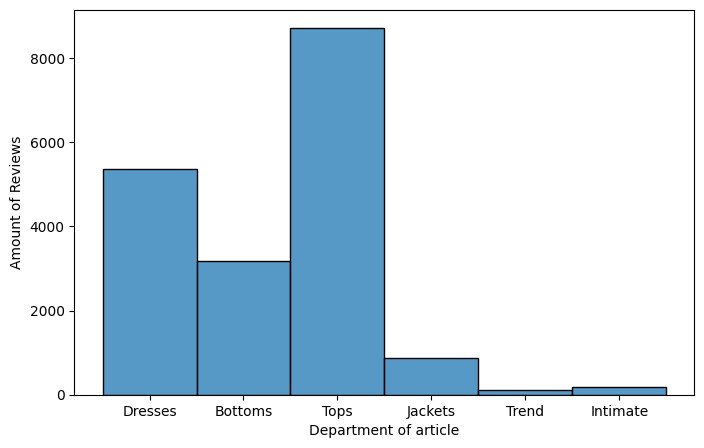

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(X["Department Name"])
plt.xlabel("Department of article")
plt.ylabel("Amount of Reviews")
plt.show()

Let's have a look at the spread of the "Positive Feedback Count"

In [11]:
X["Positive Feedback Count"].max()

np.int64(122)

### Check special characters

In [12]:
print(
    f"Amount of special characters in Review Titles: "
    f"{X['Title'].str.count(r'[^a-zA-Z0-9\s]').sum()}"
)
print(
    f"Amount of special characters in Review Text: "
    f"{X['Review Text'].str.count(r'[^a-zA-Z0-9\s]').sum()}"
)

Amount of special characters in Review Titles: 11071
Amount of special characters in Review Text: 193306


In [13]:
special_chars = (
    X['Review Text']
    .astype(str)
    .str.findall(r'[^a-zA-Z0-9\s]')
    .explode()
    .dropna()
    .value_counts()
    .to_dict()
)
display(special_chars)

{'.': 83806,
 ',': 41248,
 "'": 25474,
 '!': 11487,
 '-': 9520,
 '"': 5096,
 ')': 4454,
 '(': 4407,
 '/': 2638,
 ':': 932,
 ';': 918,
 '&': 910,
 '?': 643,
 '_': 602,
 '#': 401,
 '%': 282,
 '$': 181,
 '*': 85,
 '+': 69,
 '~': 39,
 'ã': 29,
 '©': 24,
 '=': 20,
 '<': 7,
 '@': 7,
 'â': 6,
 ']': 6,
 '[': 4,
 '>': 4,
 '¨': 4,
 '¼': 1,
 '`': 1,
 '\\': 1}

There is two unusal characters showing up which are usually not seen in an English sentence **ã** and **â**.  
The other characters don't seem unusual for a product review.

Let's have a look at the reviews which include these two special characters.

In [14]:
X[X['Review Text'].str.contains('ã', regex=False)]

,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
57,1133,33,Cute parka!,The rest of the reviewers are right about the ...,0,General,Jackets,Outerwear
2959,850,70,Retro chambray shirt,The shirt brings back the '60s look of appliqu...,1,General,Tops,Blouses
3686,1072,39,Fuzzy pink perfection,"Loving the ombrã© color combination, the smoot...",0,General,Dresses,Dresses
4164,1078,48,Absolutely gorgeous,The appliquã© on this dress is well done. i wo...,1,General,Dresses,Dresses
5787,927,59,Inspired,I am inspired to sit in front of a roaring fir...,3,General,Tops,Sweaters
6708,900,39,Draped for downtime,This is comfy and casual and fun to wear. mos...,0,General,Tops,Fine gauge
6783,1096,26,Fragile esp. around zipper,I loved this dress especially because each flo...,2,General,Dresses,Dresses
7795,860,51,Wonderful spring top,I was taking my time with this purchase i need...,0,General,Tops,Knits
8407,1083,44,Fabulous!,This gorgeous dress arrived today and i can't ...,8,General,Dresses,Dresses
10252,926,54,Vintage appeal in a soft chunky knit,This 1960s aprã¨s-ski style sweater is made of...,4,General,Tops,Sweaters


In [15]:
X[X['Review Text'].str.contains('â', regex=False)]

,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
12142,1099,43,Very flattering,I love this dress! the colors work well with m...,6,General Petite,Dresses,Dresses


We can see that the reviews in question are actually written in English but either got typos, special words or conversion issues in the string.  
Those characters will be removed later.

Having checked this we do not have to be concerned about including non English reviews and maybe messing up the machine learning algorithm later.

## Building Pipeline

First let's choose the pre-trained models we will use for the natural language processing.
We will use the spaCy en_core_web_sm model for it's lemmatizer capabilities.
Additionally we will include another pre-trained model for sentiment analysis. Here we will use the bert-base-uncased model.

In [ ]:
nlp_model = "en_core_web_sm"
sent_model = "bert-base-uncased"

access_token = None
# The access token can't be uploaded to GitHub

### Spliting Data

Let's split the features in the previously identified numerical, categorical and text categories.

In [17]:
num_features = (
    X
    .select_dtypes(exclude=['object']).columns
    .drop(
        [
            'Clothing ID',  # moved to categorical data
        ],
    )
)
print('Numerical features:', num_features)

cat_features = (
    X[[
        'Clothing ID',
        'Division Name',
        'Department Name',
    ]].columns
)
print('Categorical features:', cat_features)


text_features = (
    X[[
        'Title',
        'Review Text',
    ]].columns
)
print('Text features:', text_features)

Numerical features: Index(['Age', 'Positive Feedback Count'], dtype='object')
Categorical features: Index(['Clothing ID', 'Division Name', 'Department Name'], dtype='object')
Text features: Index(['Title', 'Review Text'], dtype='object')


### Numerical Features Pipeline

We start with the pipeline to impute and scale numerical features.
We are not interested in complete range of values for these but in bins. This is why we will use the KBinsDiscretizer.

In [18]:
num_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='mean'),
    ),
    (
        'discretizer',
        KBinsDiscretizer(n_bins=8, encode='ordinal', strategy='quantile'),
    ),
])

num_pipeline

Pipeline(steps=[('imputer', SimpleImputer()),
                ('discretizer', KBinsDiscretizer(encode='ordinal', n_bins=8))])

### Categorical Features Pipeline

For categorical data we will use:
- A simple imputer which will set unknown values to most frequent values.
- An ordinal encoder to encode the string data of Division and Department as integer
- An One-Hot encoder

In [19]:
cat_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent",
        )
    ),
    (
        "ordinal_encoder",
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )
    ),
    (
        "cat_encoder",
        OneHotEncoder(
            sparse_output=True,
            handle_unknown="ignore",
        )
    ),
])

cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('ordinal_encoder',
                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('cat_encoder', OneHotEncoder(handle_unknown='ignore'))])

### Text Feature Pipeline

Let's review our goals:  
- analyze the text of a review
- predict whether or not the customer would recommend the product


for this we will set up a pipeline with parallel:  
- Vectorization of text including Lemmatization
- Sentiment Analysis using a pretrained model via huggingface
- Length Analysis


In [20]:
# Debugging Helper
# This was used to debug issue with shape incompatibilities
# Debugging steps are commented out in the pipelines

def debug_shape(name):
    def _dbg(X):
        kind = "sparse" if sparse.issparse(X) else "dense/list"
        shape = getattr(X, "shape", None)
        try:
            length = len(X)
        except Exception:
            length = None
        print(f"[DEBUG {name}] kind={kind}, shape={shape}, len={length}")
        return X
    return FunctionTransformer(_dbg, validate=False)

To reduce memory usage we will use only sparse data as output of our text feature pipeline.  
Originally this was handled by a simple FunctionTransformer but this caused issues with later saving the trained models.

Therefore a custom transformer was needed:

In [21]:
%%capture
class ToCSR(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return sparse.csr_matrix(X)

"""
Replaces:

FunctionTransformer(
    lambda X: sparse.csr_matrix(X),
    accept_sparse=True),

to be able to pickle the fitted pipeline
"""


#### Word Count

In [22]:
class CountWords(BaseEstimator, TransformerMixin):
    def __init__(self):
        return

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [
            [len(text_input.split(' '))]
            for text_input in X
        ]

#### Lemmatizer & Tokenizer

In [23]:
nlp = spacy.load(nlp_model)

class Review_Lemmatizer(BaseEstimator, TransformerMixin):
    def __init__(self, nlp):
        self.nlp = nlp

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lemmatized = [
            ' '.join(
                token.lemma_ for token in doc
                if not token.is_stop
            )
            for doc in self.nlp.pipe(X)
        ]
        return lemmatized

After lemmatization we vectorize the outcome for later usage in the machine learning model.  
The vectorizer takes tokens whichn are created with the nlp we defined before.

To reduce memory consumption we also ensure the usage of sparse data.

In [24]:
tfidf_pipeline = Pipeline([
    # ('debug_concat', debug_shape('tfidf.concat')),
    (
        'lemmatizer',
        Review_Lemmatizer(nlp=nlp),
    ),
    # ('debug_lemma', debug_shape('tfidf.lemma')),
    (
        'tfidf_vectorizer',
        TfidfVectorizer(
            stop_words='english',
        ),
    ),
    (
        "to_sparse",
        ToCSR()
    ),
])
tfidf_pipeline

Pipeline(steps=[('lemmatizer',
                 Review_Lemmatizer(nlp=<spacy.lang.en.English object at 0x00000173B7C19FD0>)),
                ('tfidf_vectorizer', TfidfVectorizer(stop_words='english')),
                ('to_sparse', ToCSR())])

#### Sentiment Analysis

The sentiment Analysis is done with a pretrained model which we defined before.  
There were some challenges with the input strings therefore I had to check for special cases.

In [25]:
class Sentiment(BaseEstimator, TransformerMixin):
    def __init__(self, model_name=sent_model, device=None):
        self.model_name = model_name
        self.device = device
        self._tokenizer = None
        self._model = None

    def _ensure_model(self):
        if self._tokenizer is None:
            self._tokenizer = AutoTokenizer.from_pretrained(self.model_name)
        if self._model is None:
            self._model = AutoModelForSequenceClassification.from_pretrained(
                self.model_name, token=access_token
            )
            dev = self.device or (
                "cuda" if torch.cuda.is_available() else "cpu"
            )
            self._model.to(dev)
            self._device = dev

    def fit(self, X, y=None):
        return self

    def _to_text_list(self, X):
        # Normalize to a 1-D list[str]
        if hasattr(X, "to_numpy"):  # pandas Series/DataFrame
            X = X.to_numpy()
        if isinstance(X, np.ndarray):
            if X.ndim == 2 and X.shape[1] == 1:
                X = X[:, 0]
            elif X.ndim != 1:
                raise ValueError(
                    "Sentiment expects a 1-D array (or (n,1)) of strings."
                )
            X = X.tolist()
        elif isinstance(X, str):
            # Single string – treat as exactly one sample
            X = [X]
        elif not isinstance(X, (list, tuple)):
            # Generic iterable fallback
            try:
                X = list(X)
            except Exception:
                raise ValueError(
                    f"Unsupported input type for Sentiment: {type(X)}"
                )
        # Cast elements to Python str and coalesce Nones
        X = ["" if x is None else str(x) for x in X]
        return X

    def transform(self, X):
        self._ensure_model()
        texts = self._to_text_list(X)

        # Tokenize with truncation, then move tensors to the model device
        enc = self._tokenizer(
            texts,
            return_tensors='pt',
            padding=True
        )
        enc = {k: v.to(self._device) for k, v in enc.items()}

        with torch.no_grad():
            out = self._model(**enc)  # AutoModelForSequenceClassification
            logits = out.logits  # shape [B, num_labels]

        feats = logits.detach().cpu().numpy()

        # Fail fast if batch dimension got corrupted
        assert feats.shape[0] == len(texts), \
            f"Sentiment returned {feats.shape[0]} rows for {len(texts)} inputs"

        return feats  # shape: (n_samples, num_labels)


To reduce memory consumption we also ensure the usage of sparse data.

In [26]:
sentiment_pipeline = Pipeline([
    # ("debug_concat", debug_shape("sentiment.concat")),
    (
        'sentiment_analysis',
        Sentiment(
            model_name="bert-base-uncased",
            device=None
        )
    ),
    # ('debug_sent', debug_shape('sentiment.model')),
    (
        "to_sparse",
        ToCSR()
    ),
])

sentiment_pipeline

Pipeline(steps=[('sentiment_analysis', Sentiment()), ('to_sparse', ToCSR())])

#### Feature Union for text features

In [27]:
text_union = FeatureUnion([
    ('word_count', CountWords()),
    ('sentiment', sentiment_pipeline),
    ('tfidf', tfidf_pipeline)
])
text_union

FeatureUnion(transformer_list=[('word_count', CountWords()),
                               ('sentiment',
                                Pipeline(steps=[('sentiment_analysis',
                                                 Sentiment()),
                                                ('to_sparse', ToCSR())])),
                               ('tfidf',
                                Pipeline(steps=[('lemmatizer',
                                                 Review_Lemmatizer(nlp=<spacy.lang.en.English object at 0x00000173B7C19FD0>)),
                                                ('tfidf_vectorizer',
                                                 TfidfVectorizer(stop_words='english')),
                                                ('to_sparse', ToCSR())]))])

### Finalizing the Text Feature Pipeline

Our input data consists of two text columns, title and review text, we have to concatenate these. Additionally we have to ensure the datatyp as standard python string due to incompatibility of certain steps with non standard strings.

In [28]:
class ConcatTextColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, sep=" ", strip=True):
        self.columns = columns
        self.sep = sep
        self.strip = strip

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        # if we only receive a scalar string
        # instead of the two column dataframe
        if isinstance(X, (str, np.str_)):
            s = str(X)
            return [s.strip()] if self.strip else [s]

        # if we receive a 0-dim np array
        # containing a string instead of the two column dataframe
        if isinstance(X, np.ndarray) and X.ndim == 0:
            s = X.item()
            s = "" if s is None else str(s)
            return [s.strip()] if self.strip else [s]

        # Normalize to DataFrame
        if isinstance(X, pd.DataFrame):
            df = X
        elif isinstance(X, pd.Series):
            df = X.to_frame()
        elif isinstance(X, np.ndarray):
            if X.ndim == 1:
                df = pd.DataFrame({"text": X})
            elif X.ndim == 2:
                df = pd.DataFrame(X)
            else:
                raise ValueError(
                    f"Unsupported ndarray ndim={X.ndim} for text input."
                )
        else:
            # Generic iterable → DataFrame
            # if it's already list[str], this becomes (n,1).
            df = pd.DataFrame(X)

        # fill NA then cast to Python-string dtype when available
        try:
            df = df.fillna("").astype("string[python]")
        except Exception:
            df = df.fillna("").astype(str)

        # Build exactly one string per row
        if df.shape[1] == 1:
            texts = df.iloc[:, 0].tolist()
        else:
            texts = (
                df.apply(
                    lambda row: self.sep.join(map(str, row.values.tolist())),
                    axis=1
                )
                .tolist()
            )

        if self.strip:
            texts = [t.strip() for t in texts]

        # Guarantee Python str elements
        texts = ["" if t is None else str(t) for t in texts]
        return texts

In [29]:
text_pipeline = Pipeline([
    (
        'concat',
        ConcatTextColumns(
            sep=" ",
            strip=True
        )
    ),
    (
        'union',
        text_union
    ),
])

text_pipeline

Pipeline(steps=[('concat', ConcatTextColumns()),
                ('union',
                 FeatureUnion(transformer_list=[('word_count', CountWords()),
                                                ('sentiment',
                                                 Pipeline(steps=[('sentiment_analysis',
                                                                  Sentiment()),
                                                                 ('to_sparse',
                                                                  ToCSR())])),
                                                ('tfidf',
                                                 Pipeline(steps=[('lemmatizer',
                                                                  Review_Lemmatizer(nlp=<spacy.lang.en.English object at 0x00000173B7C19FD0>)),
                                                                 ('tfidf_vectorizer',
                                                                  TfidfVectorizer(stop_words='english')),
                                                                 ('to_sparse',
                                                                  ToCSR())]))]))])

### Pipeline Assembly

First we define our Feature Engineering with all steps described before.

In [30]:
feature_engineering = ColumnTransformer([
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features),
        ('text', text_pipeline, text_features),
], remainder='drop')

feature_engineering

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('discretizer',
                                                  KBinsDiscretizer(encode='ordinal',
                                                                   n_bins=8))]),
                                 Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal_encoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknow...
                                                                                  CountWords()),
                                                                                 ('sentiment',
                                                                                  Pipeline(steps=[('sentiment_analysis',
                                                                                                   Sentiment()),
                                                                                                  ('to_sparse',
                                                                                                   ToCSR())])),
                                                                                 ('tfidf',
                                                                                  Pipeline(steps=[('lemmatizer',
                                                                                                   Review_Lemmatizer(nlp=<spacy.lang.en.English object at 0x00000173B7C19FD0>)),
                                                                                                  ('tfidf_vectorizer',
                                                                                                   TfidfVectorizer(stop_words='english')),
                                                                                                  ('to_sparse',
                                                                                                   ToCSR())]))]))]),
                                 Index(['Title', 'Review Text'], dtype='object'))])

Then we add a random forest to analyze and predict.

In [31]:
model_pipeline = Pipeline([
    (
        "feature_engineering",
        feature_engineering
    ),
    (
        "rf",
        RandomForestClassifier(
            random_state=23
        )
    ),
])

model_pipeline

Pipeline(steps=[('feature_engineering',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('discretizer',
                                                                   KBinsDiscretizer(encode='ordinal',
                                                                                    n_bins=8))]),
                                                  Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal_encoder',
                                                                   OrdinalEncoder(ha...
                                                                                                   Pipeline(steps=[('sentiment_analysis',
                                                                                                                    Sentiment()),
                                                                                                                   ('to_sparse',
                                                                                                                    ToCSR())])),
                                                                                                  ('tfidf',
                                                                                                   Pipeline(steps=[('lemmatizer',
                                                                                                                    Review_Lemmatizer(nlp=<spacy.lang.en.English object at 0x00000173B7C19FD0>)),
                                                                                                                   ('tfidf_vectorizer',
                                                                                                                    TfidfVectorizer(stop_words='english')),
                                                                                                                   ('to_sparse',
                                                                                                                    ToCSR())]))]))]),
                                                  Index(['Title', 'Review Text'], dtype='object'))])),
                ('rf', RandomForestClassifier(random_state=23))])

## Training Pipeline

Due to memory constraints we cannot fit the full pipeline in one step.

First we will fit the feature engineering part seperately and save it to a pickle file.

In [32]:
feat_eng_path = Path(os.path.join(model_path, "feature_engineering.pkl"))
if small_model:
    feat_eng_path = Path(
        os.path.join(
            model_path,
            "feature_engineering_small.pkl"
        )
    )

if feat_eng_path.is_file() and retrain is False:
    frozen_feat_eng = joblib.load(feat_eng_path)
    print("Saved feature engineering model loaded.")

else:
    if small_model:
        model_pipeline.set_params(
            feature_engineering__text__union__sentiment='drop'
        )

    model_pipeline.named_steps['feature_engineering'].fit(X_train, y_train)
    frozen_feat_eng = model_pipeline.named_steps['feature_engineering']
    if save_model:
        os.makedirs(os.path.dirname(feat_eng_path), exist_ok=True)
        joblib.dump(
            frozen_feat_eng,
            feat_eng_path,
            protocol=pickle.HIGHEST_PROTOCOL
        )
        print(
            f"Feature engineering model saved with pickle protocol "
            f"{pickle.HIGHEST_PROTOCOL}."
        )

C:\Users\G39VQNW\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_discretization.py:307: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(


Feature engineering model saved with pickle protocol 5.


Next we transform the training data and save it to a npz file.

In [33]:
X_train_path = Path(os.path.join(model_path, "X_train_transformed.npz"))
if small_model:
    X_train_path = Path(
        os.path.join(
            model_path,
            "X_train_transformed_small.npz"
        )
    )

if X_train_path.is_file() and retrain is False:
    X_train_transformed = sparse.load_npz(X_train_path)
    print("Transformed training data loaded.")

else:
    X_train_transformed = frozen_feat_eng.transform(X_train).astype(np.float32)
    if save_model:
        os.makedirs(os.path.dirname(X_train_path), exist_ok=True)
        sparse.save_npz(X_train_path, X_train_transformed)
        print("Transformed training data saved.")

Transformed training data saved.


We load the big model if the respective variable was set.

In [34]:
if fit_small_load_big and small_model and retrain:
    feat_eng_path = Path(os.path.join(model_path, "feature_engineering.pkl"))
    if feat_eng_path.is_file():
        frozen_feat_eng = joblib.load(feat_eng_path)
        print("Saved feature engineering model (big) loaded.")

    X_train_path = Path(os.path.join(model_path, "X_train_transformed.npz"))
    if X_train_path.is_file():
        X_train_transformed = sparse.load_npz(X_train_path)
        print("Transformed training data (big) loaded.")

Saved feature engineering model (big) loaded.
Transformed training data (big) loaded.


Then we train the random forest.

In [35]:
rand_forest_path = Path(os.path.join(model_path, "random_forest.pkl"))

if rand_forest_path.is_file() and retrain is False:
    frozen_rand_forest = joblib.load(rand_forest_path)
    print("Saved random forest model loaded.")

else:
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=23
    )
    rf.fit(X_train_transformed, y_train)
    frozen_rand_forest = rf
    if save_model:
        os.makedirs(os.path.dirname(rand_forest_path), exist_ok=True)
        joblib.dump(rf, rand_forest_path, protocol=pickle.HIGHEST_PROTOCOL)
        print(
            f"Random forest model saved with pickle protocol "
            f"{pickle.HIGHEST_PROTOCOL}."
        )

Random forest model saved with pickle protocol 5.


Below part was used for training in batches until I realized it is not needed.  
(The most ressource intensive part of this pipeline is the feature engineering)

Anyways the code will be kept for documentation and learning

In [36]:
%%capture
"""
else:
    # define new forest
    forest_size = 100 # approx size
    batch_size = 980
    
    batches = divmod(len(X_train), batch_size)[0]
    trees_per_batch = divmod(forest_size, batches)[0]
    
    rf = RandomForestClassifier(
        n_estimators=0,
        warm_start=True,
        bootstrap=True,
        n_jobs=-1,
        random_state=23
    )
    
    perm = np.random.permutation(len(X_train))
    
    for start in range(0, len(X_train), batch_size):
        batch_idx = perm[start:start + batch_size]
        Xb = X.iloc[batch_idx]
        yb = y.iloc[batch_idx]
    
        # Transform batch using frozen feature_engineering
        Xt = frozen_feat_eng.transform(Xb)
        Xt = Xt.astype(np.float32)
    
        rf.set_params(n_estimators=rf.n_estimators + trees_per_batch)
        rf.fit(Xt, yb)
    
    # Save the trained model
    
    joblib.dump(rf, "random_forest.pkl")
    frozen_rand_forest = rf

"""

Finally we assemble the pipeline again

In [37]:
model_pipeline = Pipeline([
    ("feature_engineering", frozen_feat_eng),
    ("random_forest", frozen_rand_forest),
])
model_pipeline

Pipeline(steps=[('feature_engineering',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('discretizer',
                                                                   KBinsDiscretizer(encode='ordinal',
                                                                                    n_bins=8))]),
                                                  Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal_encoder',
                                                                   OrdinalEncoder(ha...
                                                                                                                   ('to_sparse',
                                                                                                                    ToCSR())])),
                                                                                                  ('tfidf',
                                                                                                   Pipeline(steps=[('lemmatizer',
                                                                                                                    Review_Lemmatizer(nlp=<spacy.lang.en.English object at 0x00000173BDE32710>)),
                                                                                                                   ('tfidf_vectorizer',
                                                                                                                    TfidfVectorizer(stop_words='english')),
                                                                                                                   ('to_sparse',
                                                                                                                    ToCSR())]))]))]),
                                                  Index(['Title', 'Review Text'], dtype='object'))])),
                ('random_forest',
                 RandomForestClassifier(n_estimators=300, random_state=23))])

After reassembly let's check the accuracy of our model:

In [38]:
y_pred_forest_pipeline = model_pipeline.predict(X_test)
accuracy_forest_pipeline = accuracy_score(y_test, y_pred_forest_pipeline)

print('Accuracy:', accuracy_forest_pipeline)

Accuracy: 0.8579945799457994


## Fine-Tuning Pipeline

Before choosing the parameters to fine tune let us a have a look which parameters there are.

In [39]:
for key in model_pipeline.get_params().keys():
    print(key)

memory
steps
verbose
feature_engineering
random_forest
feature_engineering__force_int_remainder_cols
feature_engineering__n_jobs
feature_engineering__remainder
feature_engineering__sparse_threshold
feature_engineering__transformer_weights
feature_engineering__transformers
feature_engineering__verbose
feature_engineering__verbose_feature_names_out
feature_engineering__num
feature_engineering__cat
feature_engineering__text
feature_engineering__num__memory
feature_engineering__num__steps
feature_engineering__num__verbose
feature_engineering__num__imputer
feature_engineering__num__discretizer
feature_engineering__num__imputer__add_indicator
feature_engineering__num__imputer__copy
feature_engineering__num__imputer__fill_value
feature_engineering__num__imputer__keep_empty_features
feature_engineering__num__imputer__missing_values
feature_engineering__num__imputer__strategy
feature_engineering__num__discretizer__dtype
feature_engineering__num__discretizer__encode
feature_engineering__num__dis

Due to ressource limitations we will only use parameters of the random forest in this exercise:

In [40]:
frozen_rand_forest.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 23,
 'verbose': 0,
 'warm_start': False}

We will do two runs of optimization.  
The first run we start with a broad scope:

In [41]:
param_distributions = {
    "n_estimators": randint(100, 800),
    "max_depth": randint(5, 50),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": uniform(0.1, 0.9),
}

If more computing ressources would be available I would propose to try the following paramters in feature engineering too:
- feature_engineering__num__discretizer__n_bins
  - 4-8 bins
- feature_engineering__num__discretizer__strategy
  - "onehot", "ordinal"
- feature_engineering__num__discretizer__encode
  - "uniform", "quantile", "kmeans"
- feature_engineering__text__union__tfidf__tfidf_vectorizer__ngram_range 
  - (1, 1), (1, 2), (1, 3)
- feature_engineering__text__union__sentiment__sentiment_analysis__model_name
  - trying a different model

Since we only tune the random forest we will not call the randomized search cv over the whole pipeline but only the random forest.  
Then build a new optimized pipeline afterwards.

In [42]:
opt_forest_path = Path(os.path.join(model_path, "opt_forest.pkl"))

if opt_forest_path.is_file() and retrain is False:
    frozen_opt_forest = joblib.load(opt_forest_path)
    print("Saved optimized forest model loaded.")

else:
    search = RandomizedSearchCV(
        estimator=frozen_rand_forest,
        param_distributions=param_distributions,
        n_iter=30,
        cv=3,
        n_jobs=-1,
        verbose=2,
        random_state=23,
    )
    search.fit(X_train_transformed, y_train)
    frozen_opt_forest = search.best_estimator_
    if save_model:
        os.makedirs(os.path.dirname(opt_forest_path), exist_ok=True)
        joblib.dump(
            frozen_opt_forest,
            opt_forest_path,
            protocol=pickle.HIGHEST_PROTOCOL
        )
        print(
            f"Optimized forest model saved with pickle protocol "
            f"{pickle.HIGHEST_PROTOCOL}."
        )

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Optimized forest model saved with pickle protocol 5.


Building the optimized pipeline:

In [43]:
optimized_pipeline = Pipeline([
    ("feature_engineering", frozen_feat_eng),
    ("random_forest", frozen_opt_forest),
])
optimized_pipeline

Pipeline(steps=[('feature_engineering',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('discretizer',
                                                                   KBinsDiscretizer(encode='ordinal',
                                                                                    n_bins=8))]),
                                                  Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal_encoder',
                                                                   OrdinalEncoder(ha...
                                                                                                                    Review_Lemmatizer(nlp=<spacy.lang.en.English object at 0x00000173BDE32710>)),
                                                                                                                   ('tfidf_vectorizer',
                                                                                                                    TfidfVectorizer(stop_words='english')),
                                                                                                                   ('to_sparse',
                                                                                                                    ToCSR())]))]))]),
                                                  Index(['Title', 'Review Text'], dtype='object'))])),
                ('random_forest',
                 RandomForestClassifier(max_depth=47,
                                        max_features=np.float64(0.18996983827644903),
                                        min_samples_leaf=2,
                                        min_samples_split=16, n_estimators=665,
                                        random_state=23))])

And checking the accuracy:

In [44]:
y_pred_opt_forest_pipeline = optimized_pipeline.predict(X_test)
accuracy_opt_forest_pipeline = accuracy_score(
    y_test,
    y_pred_opt_forest_pipeline
)

print('Accuracy:', accuracy_opt_forest_pipeline)

Accuracy: 0.867750677506775


We will do a second run of optimization in a narrower area around the previous found opimized parameters.

In [45]:
frozen_opt_forest.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 47,
 'max_features': np.float64(0.18996983827644903),
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 2,
 'min_samples_split': 16,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 665,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 23,
 'verbose': 0,
 'warm_start': False}

In [46]:
current = frozen_opt_forest.get_params()
param_distributions_sec = {
    "n_estimators": randint(
        max(10, current["n_estimators"] - 150),
        current["n_estimators"] + 150
    ),
    "max_depth": randint(
        max(1, current["max_depth"] - 5),
        current["max_depth"] + 5
    ),
    "min_samples_split": randint(
        max(2, current["min_samples_split"] - 3),
        current["min_samples_split"] + 3
    ),
    "min_samples_leaf": randint(
        max(1, current["min_samples_leaf"] - 2),
        current["min_samples_leaf"] + 2
    ),
    "max_features": uniform(
        max(0.01, current["max_features"] - 0.1),
        0.2
    ),
}

In [47]:
final_forest_path = Path(os.path.join(model_path, "final_forest.pkl"))

if final_forest_path.is_file() and retrain is False:
    frozen_final_forest = joblib.load(final_forest_path)
    print("Saved final forest model loaded.")

else:
    search_final = RandomizedSearchCV(
        estimator=frozen_opt_forest,
        param_distributions=param_distributions_sec,
        n_iter=30,
        cv=3,
        n_jobs=-1,
        verbose=2,
        random_state=23,
    )
    search_final.fit(X_train_transformed, y_train)
    frozen_final_forest = search_final.best_estimator_
    if save_model:
        os.makedirs(os.path.dirname(final_forest_path), exist_ok=True)
        joblib.dump(
            frozen_final_forest,
            final_forest_path,
            protocol=pickle.HIGHEST_PROTOCOL
        )
        print(
            f"Final forest model saved with pickle protocol "
            f"{pickle.HIGHEST_PROTOCOL}."
        )

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Final forest model saved with pickle protocol 5.


Again building the final pipeline:

In [48]:
final_pipeline = Pipeline([
    ("feature_engineering", frozen_feat_eng),
    ("random_forest", frozen_final_forest),
])
final_pipeline

Pipeline(steps=[('feature_engineering',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('discretizer',
                                                                   KBinsDiscretizer(encode='ordinal',
                                                                                    n_bins=8))]),
                                                  Index(['Age', 'Positive Feedback Count'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal_encoder',
                                                                   OrdinalEncoder(ha...
                                                                                                                    Review_Lemmatizer(nlp=<spacy.lang.en.English object at 0x00000173BDE32710>)),
                                                                                                                   ('tfidf_vectorizer',
                                                                                                                    TfidfVectorizer(stop_words='english')),
                                                                                                                   ('to_sparse',
                                                                                                                    ToCSR())]))]))]),
                                                  Index(['Title', 'Review Text'], dtype='object'))])),
                ('random_forest',
                 RandomForestClassifier(max_depth=46,
                                        max_features=np.float64(0.11209834997454822),
                                        min_samples_leaf=2,
                                        min_samples_split=17, n_estimators=797,
                                        random_state=23))])

And checking the accuracy:

In [49]:
y_pred_final_forest_pipeline = final_pipeline.predict(X_test)
accuracy_final_forest_pipeline = accuracy_score(
    y_test,
    y_pred_final_forest_pipeline
)

print('Accuracy:', accuracy_final_forest_pipeline)

Accuracy: 0.8682926829268293


# Results and Verdict

Let's compare the accuracy before and after otpimization:

In [50]:
print('Initial pipeline accuracy:', accuracy_forest_pipeline)
print('Optimized pipeline accuracy:', accuracy_opt_forest_pipeline)
print('Final pipeline accuracy:', accuracy_final_forest_pipeline)

Initial pipeline accuracy: 0.8579945799457994
Optimized pipeline accuracy: 0.867750677506775
Final pipeline accuracy: 0.8682926829268293


We did small improvements by adjusting the random forest parameters.  
Overall I am satisified with the progress in this challenge but the missing computation power realy slowed down work and I had to scale back my expectations accordingly.

In the last cell below let us have a look at one example of misclassified data.

In [51]:
misclassified_mask = y_pred_final_forest_pipeline != y_test
misclassified_indices = np.where(misclassified_mask)[0]

review_display = random.choice(misclassified_indices)

display(X_test.iloc[review_display]["Title"])
display(X_test.iloc[review_display]["Review Text"])
print(
    f"\nThis review should have been classified as"
    f"{'positive' if y[review_display] == 1 else 'negative'}"
    f"but was misclassified."
)

'Fun sweatshirt'

"Cute sweatshirt with fun print. i bought it using retailer discount, and probably would not have paid full price for it. embroidery is a nice touch. i ordered an xs, which fits fine, but the overall design of the shirt is a little short and boxy. i did not realize until it arrived that the back of the shirt is a v neck. it's not a deep v, but it feels a little odd at first."


This review should have been classified aspositivebut was misclassified.
